In [14]:
import pandas as pd
from sqlalchemy import create_engine

# Database connection
DB_USER = "apple"
DB_PASSWORD = "newStrongPassword123"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "kush"

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

# Extract daily data
daily_df = pd.read_sql("SELECT * FROM daily_stock_data", con=engine, parse_dates=['date'])

# Optional: weekly and monthly
weekly_df = pd.read_sql("SELECT * FROM weekly_stock_summary", con=engine, parse_dates=['date'])
monthly_df = pd.read_sql("SELECT * FROM monthly_stock_summary", con=engine, parse_dates=['date'])

print(daily_df.head())
print(weekly_df.head())
print(monthly_df.head())


  symbol exchange                      date    open    high     low   close  \
0   AAPL     XNAS 2025-02-11 00:00:00+00:00  228.20  235.23  228.13  232.62   
1   AAPL     XNAS 2025-02-12 00:00:00+00:00  231.20  236.96  230.68  236.87   
2   AAPL     XNAS 2025-02-13 00:00:00+00:00  236.91  242.34  235.57  241.53   
3   AAPL     XNAS 2025-02-14 00:00:00+00:00  241.25  245.55  240.99  244.60   
4   AAPL     XNAS 2025-02-18 00:00:00+00:00  243.91  245.18  241.84  244.47   

     volume  split_factor  dividend  daily_return        ma_7       ma_30  
0  53677600           1.0       0.0      0.019369  232.620000  232.620000  
1  45243300           1.0       0.0      0.024524  234.745000  234.745000  
2  53543300           1.0       0.0      0.019501  237.006667  237.006667  
3  40896227           1.0       0.0      0.013886  238.905000  238.905000  
4  48158313           1.0       0.0      0.002296  240.018000  240.018000  
  symbol                      date      open      high     low    clo

In [42]:
print(daily_df.columns)
print(weekly_df.columns)
print(monthly_df.columns)


Index(['symbol', 'exchange', 'date', 'open', 'high', 'low', 'close', 'volume',
       'split_factor', 'dividend', 'daily_return', 'ma_7', 'ma_30'],
      dtype='object')
Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume',
       'daily_return'],
      dtype='object')
Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume',
       'daily_return', 'cumulative_return'],
      dtype='object')


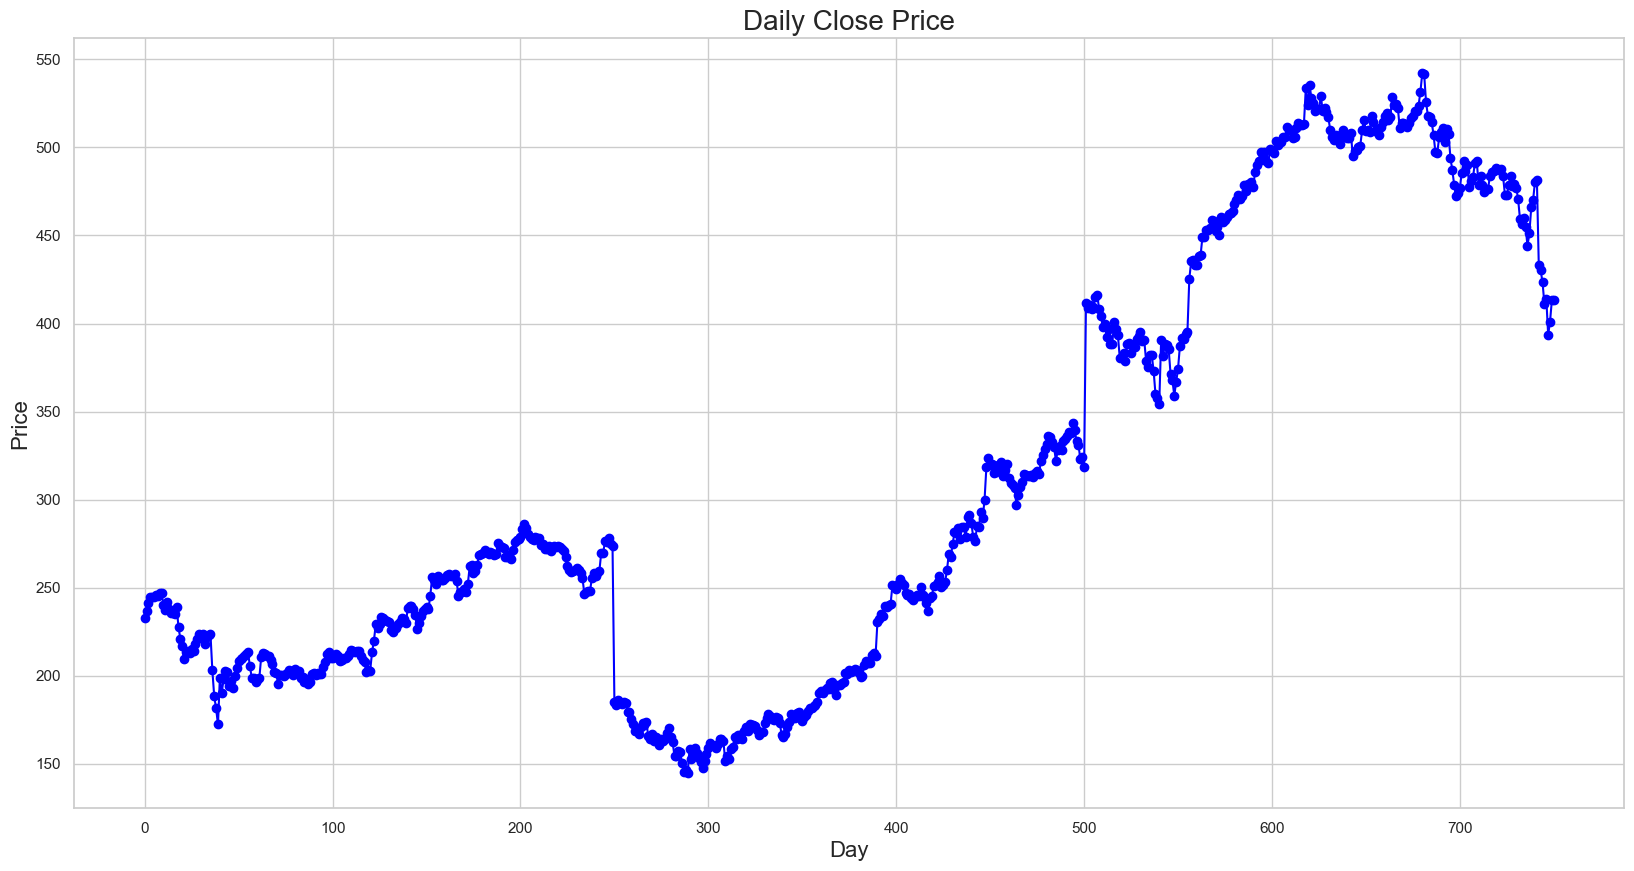

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plt.plot(daily_df.index, daily_df['close'], color='blue', marker='o')
plt.title("Daily Close Price", fontsize=20)
plt.xlabel("Day", fontsize=16)
plt.ylabel("Price", fontsize=16)
plt.grid(True)

plt.show()



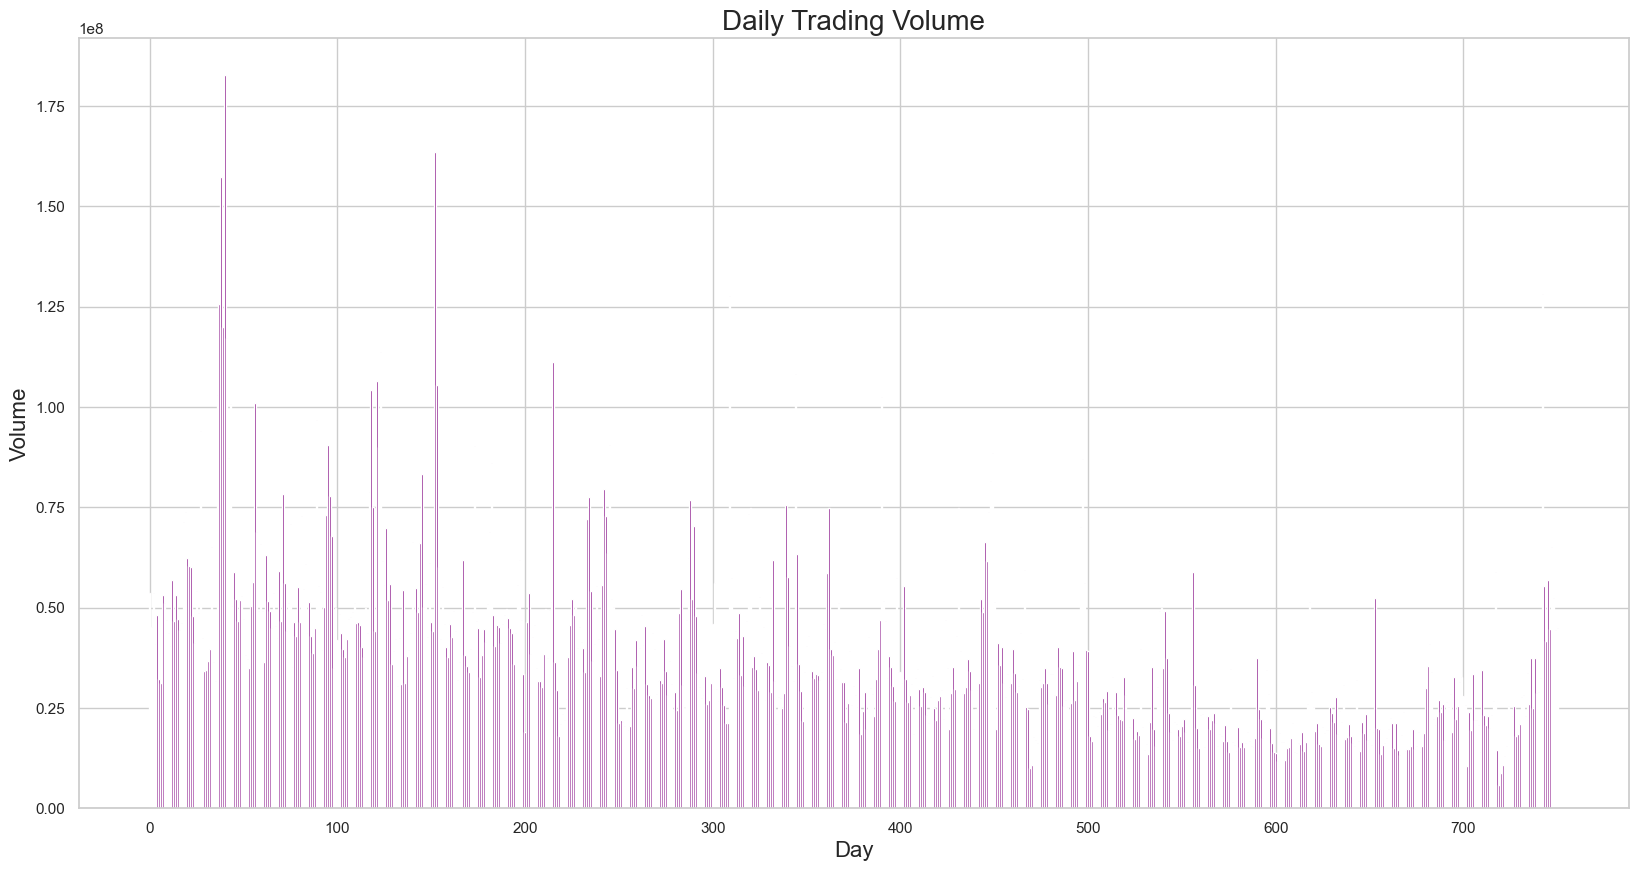

In [53]:
plt.figure(figsize=(20,10))
plt.bar(daily_df.index, daily_df['volume'], color='purple')
plt.title("Daily Trading Volume", fontsize=20)
plt.xlabel("Day", fontsize=16)
plt.ylabel("Volume", fontsize=16)
plt.show()


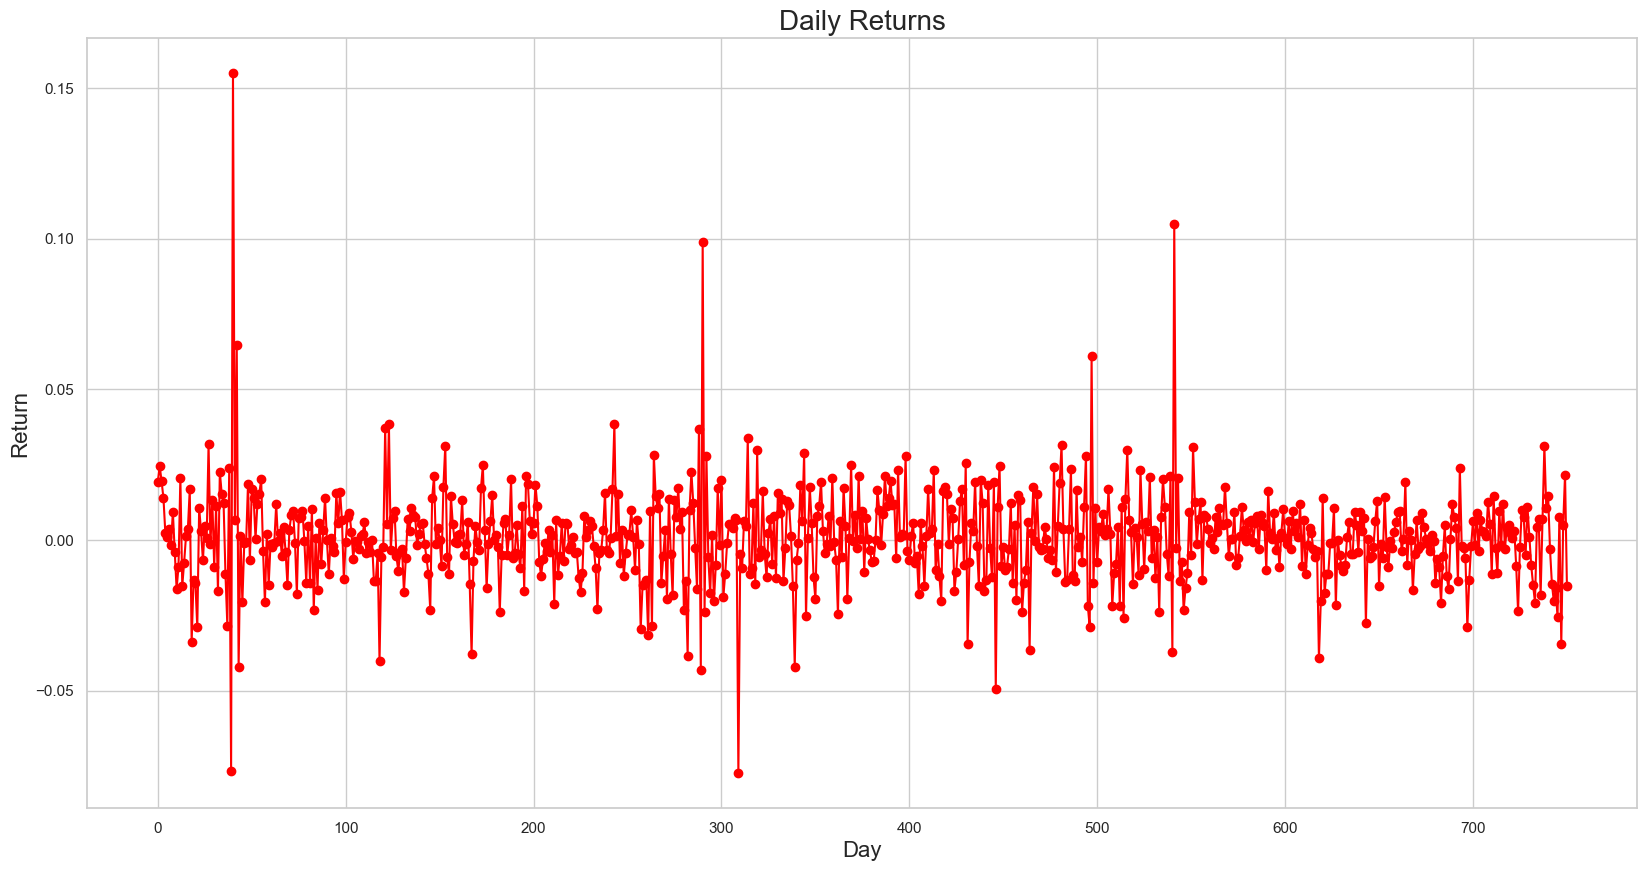

In [54]:
plt.figure(figsize=(20,10))
plt.plot(daily_df.index, daily_df['daily_return'], color='red', marker='o')
plt.title("Daily Returns", fontsize=20)
plt.xlabel("Day", fontsize=16)
plt.ylabel("Return", fontsize=16)
plt.grid(True)
plt.show()


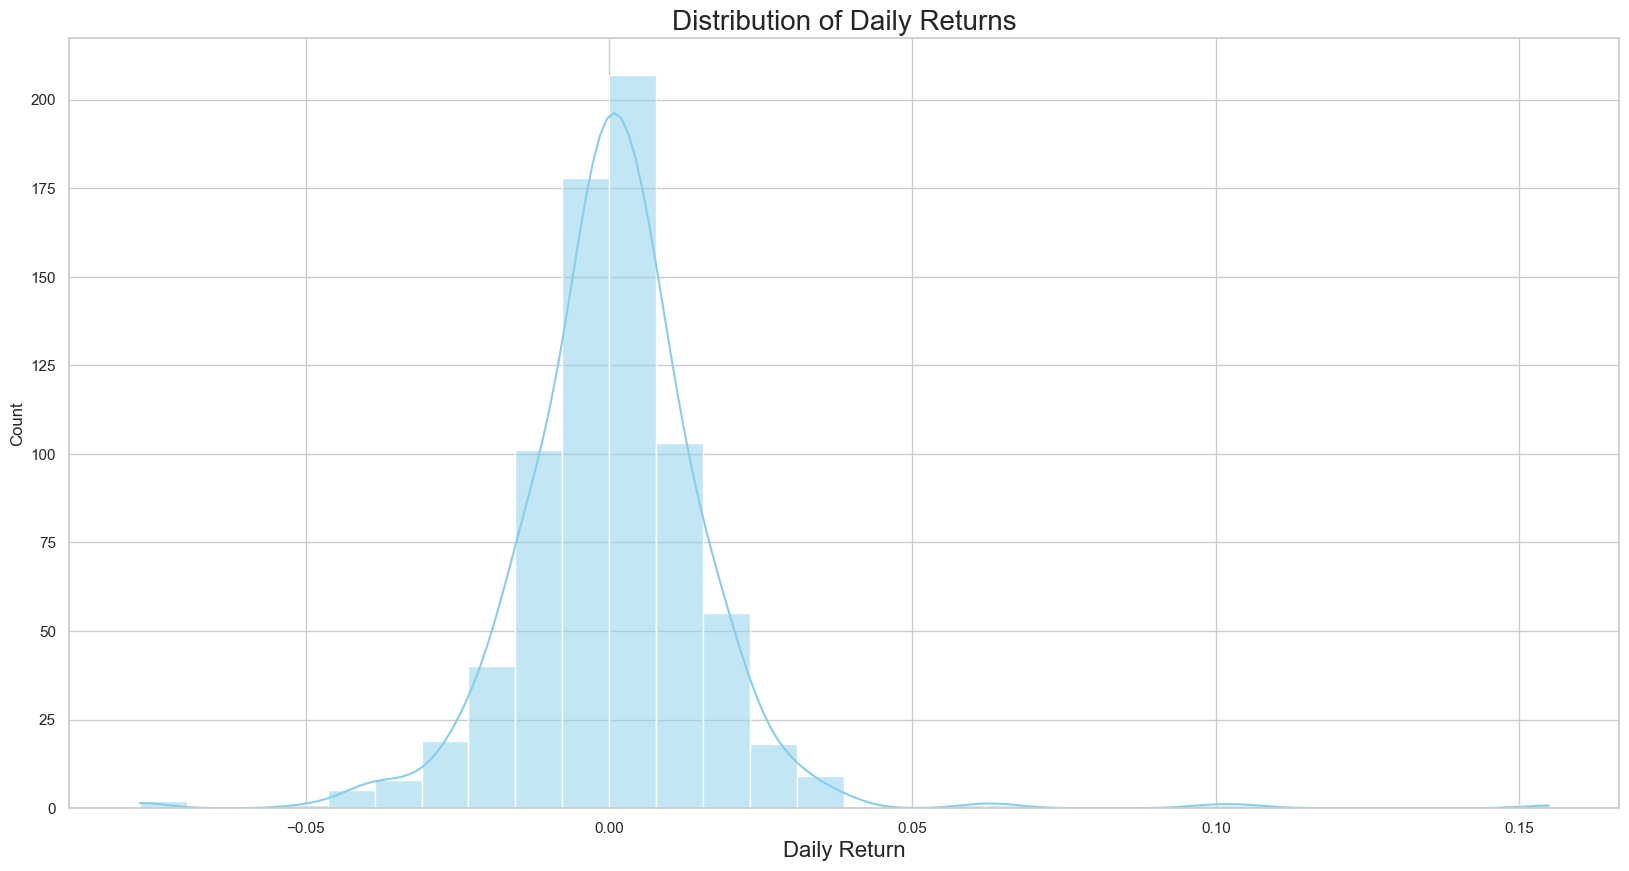

In [55]:
plt.figure(figsize=(20,10))
sns.histplot(daily_df['daily_return'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Daily Returns", fontsize=20)
plt.xlabel("Daily Return", fontsize=16)
plt.show()

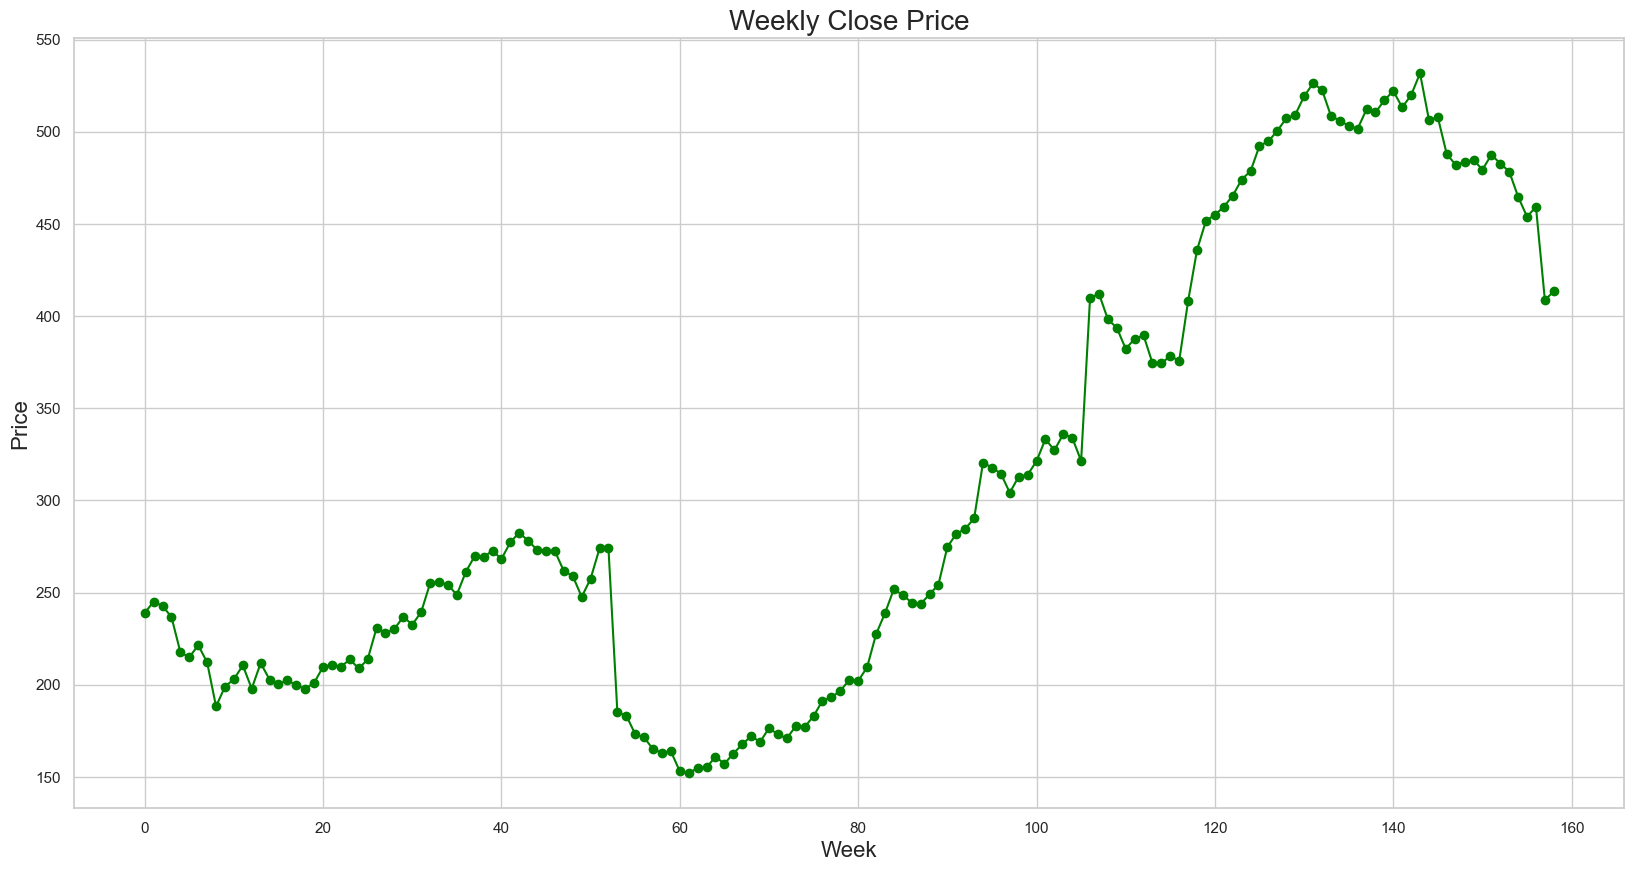

In [56]:
plt.figure(figsize=(20,10))
plt.plot(weekly_df.index, weekly_df['close'], color='green', marker='o')
plt.title("Weekly Close Price", fontsize=20)
plt.xlabel("Week", fontsize=16)
plt.ylabel("Price", fontsize=16)
plt.grid(True)
plt.show()

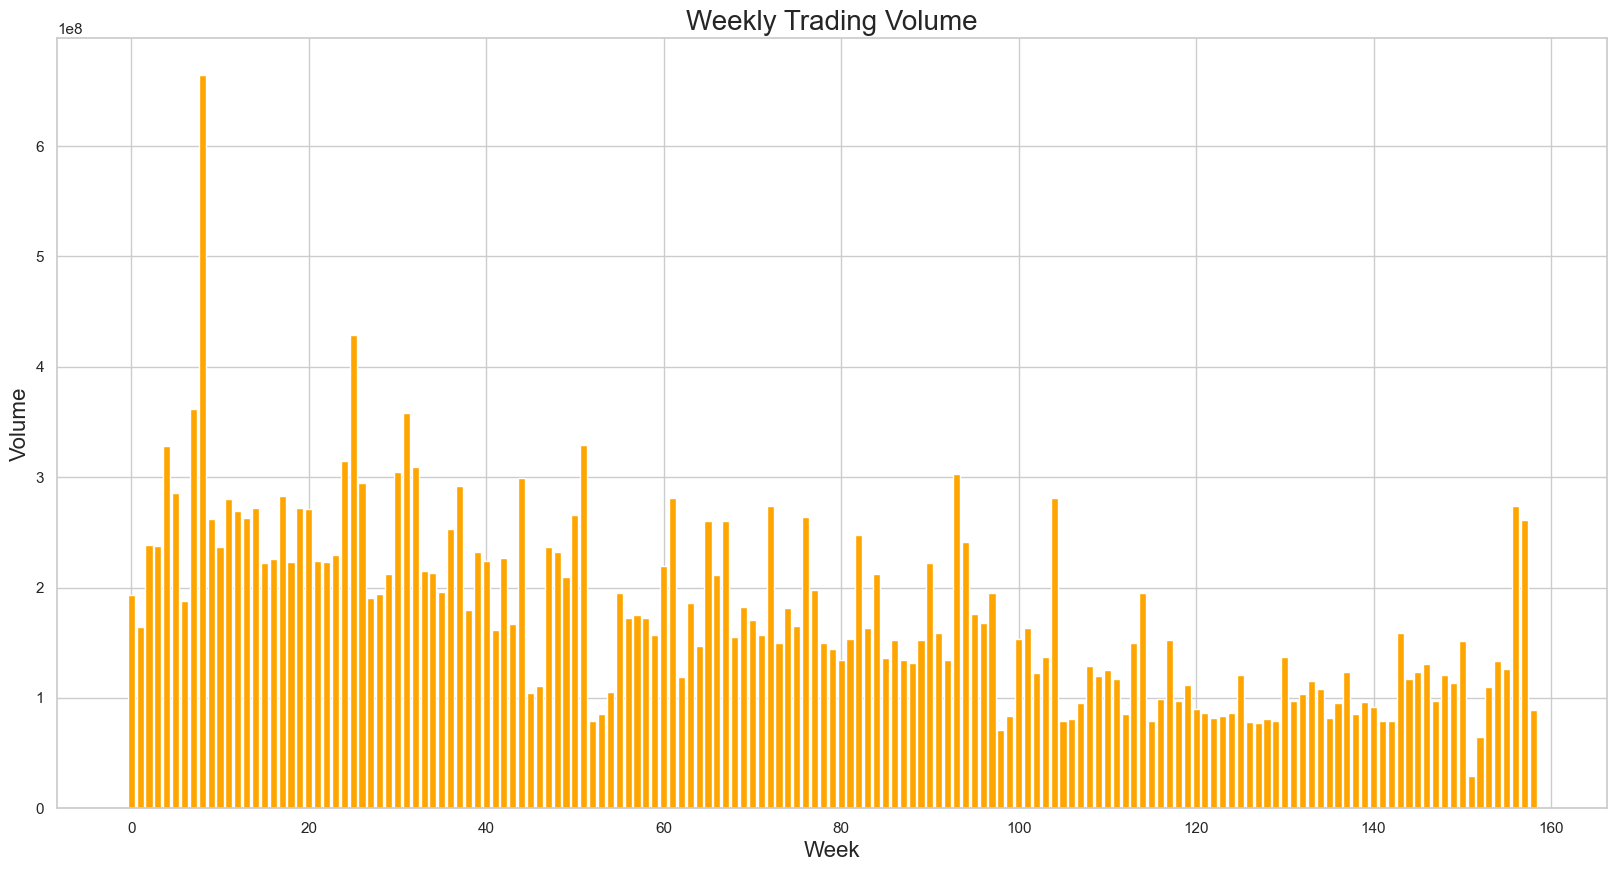

In [57]:
plt.figure(figsize=(20,10))
plt.bar(weekly_df.index, weekly_df['volume'], color='orange')
plt.title("Weekly Trading Volume", fontsize=20)
plt.xlabel("Week", fontsize=16)
plt.ylabel("Volume", fontsize=16)
plt.show()


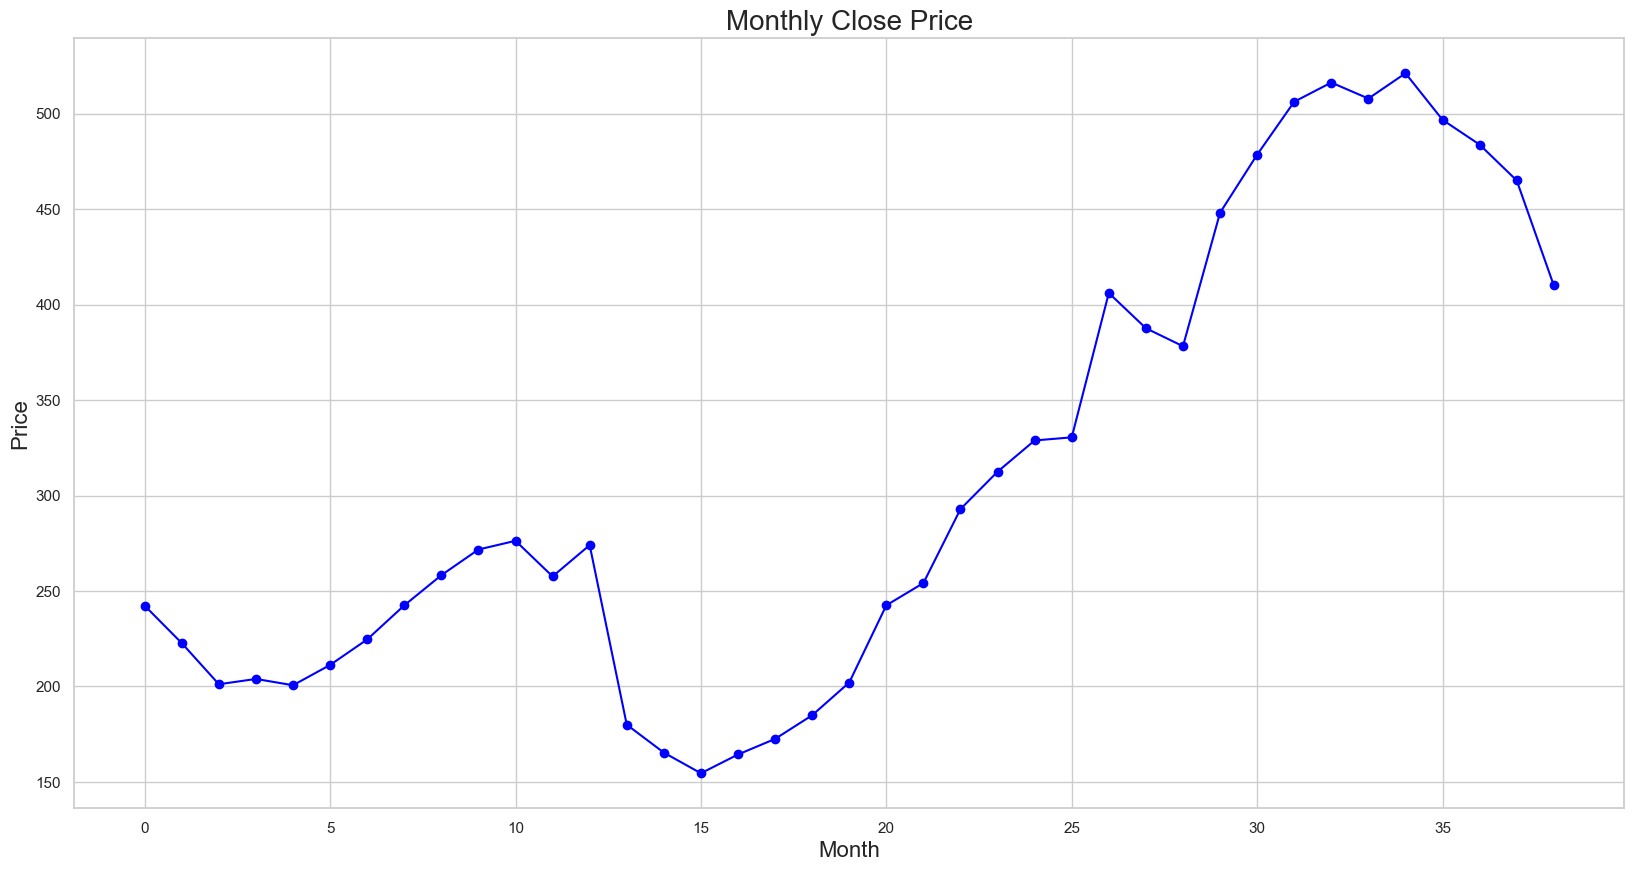

In [58]:
plt.figure(figsize=(20,10))
plt.plot(monthly_df.index, monthly_df['close'], color='blue', marker='o')
plt.title("Monthly Close Price", fontsize=20)
plt.xlabel("Month", fontsize=16)
plt.ylabel("Price", fontsize=16)
plt.grid(True)
plt.show()


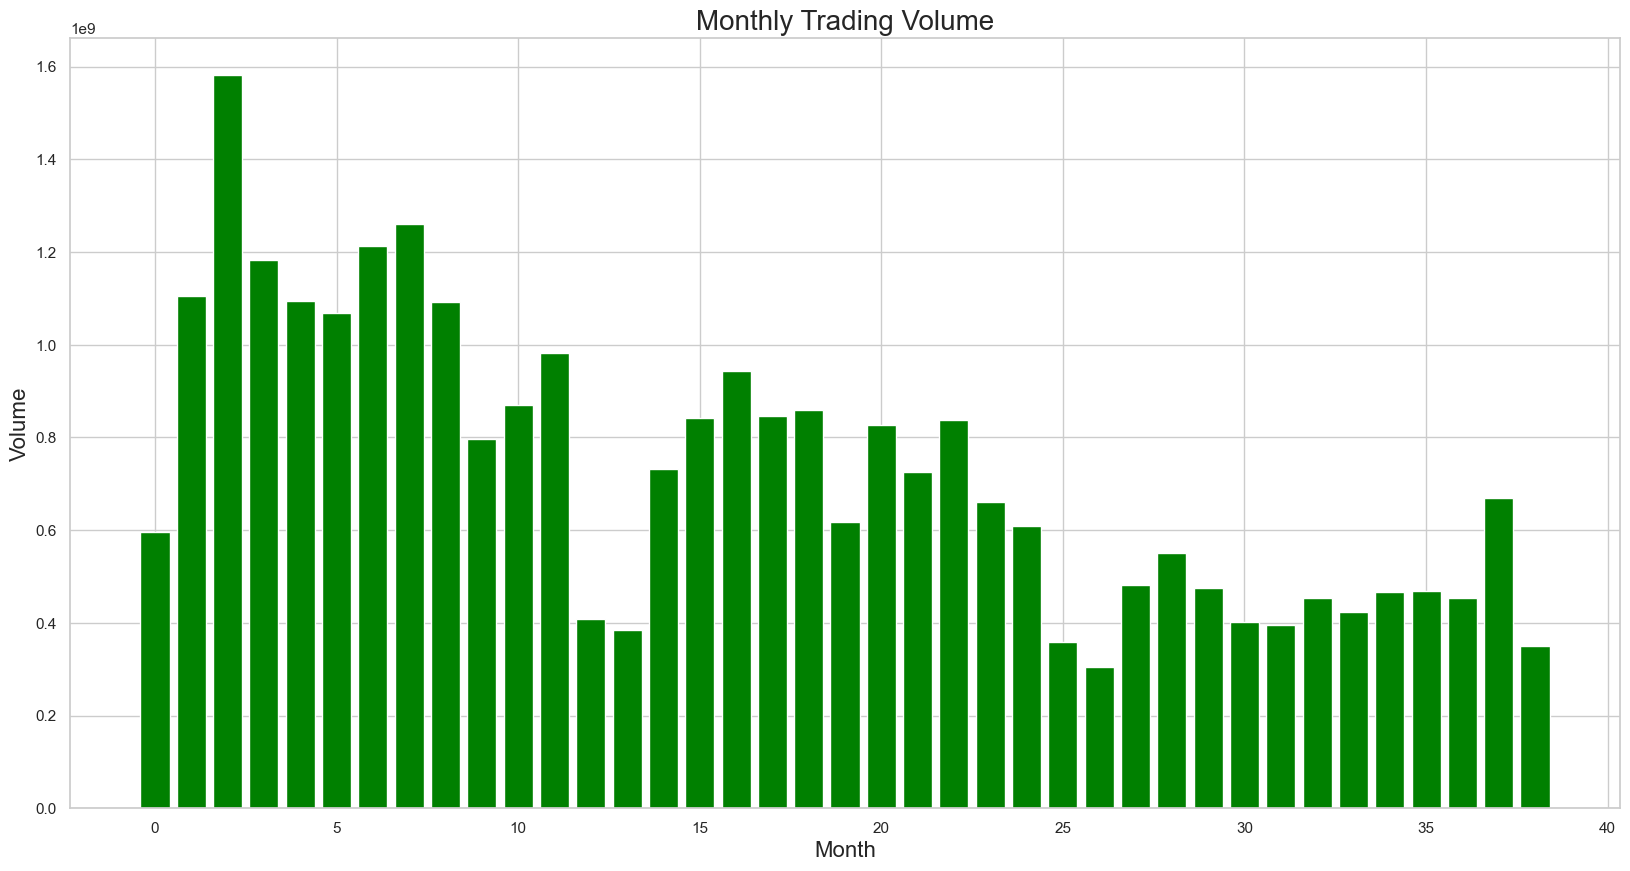

In [59]:
plt.figure(figsize=(20,10))
plt.bar(monthly_df.index, monthly_df['volume'], color='green')
plt.title("Monthly Trading Volume", fontsize=20)
plt.xlabel("Month", fontsize=16)
plt.ylabel("Volume", fontsize=16)
plt.show()


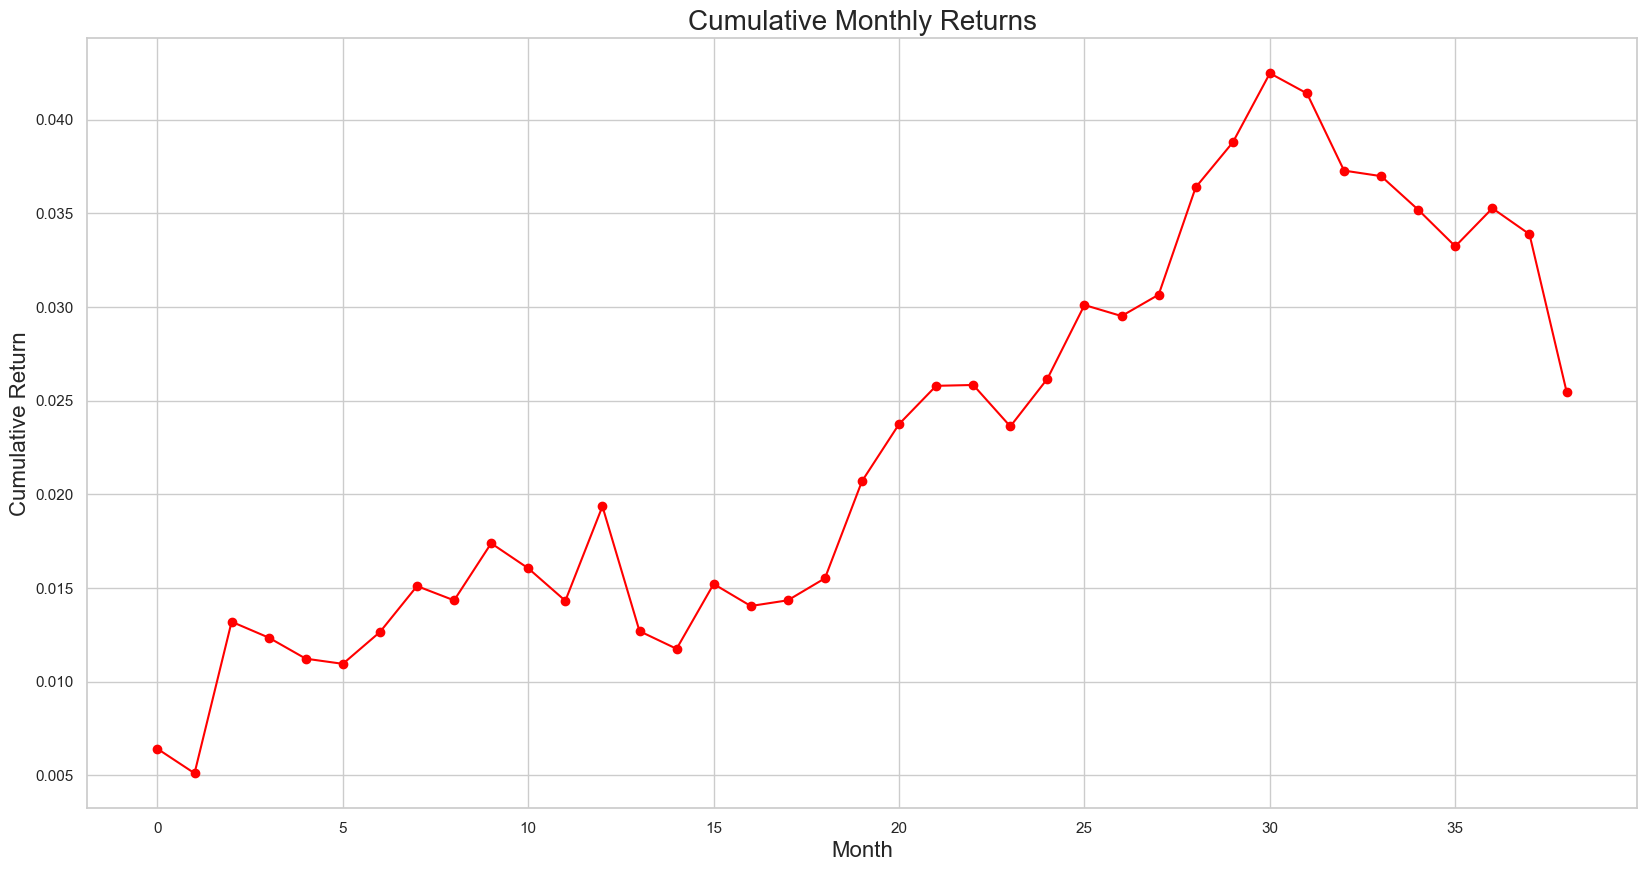

In [60]:
monthly_df['cumulative_return'] = (1 + monthly_df['daily_return']).cumprod() - 1

plt.figure(figsize=(20,10))
plt.plot(monthly_df.index, monthly_df['cumulative_return'], color='red', marker='o')
plt.title("Cumulative Monthly Returns", fontsize=20)
plt.xlabel("Month", fontsize=16)
plt.ylabel("Cumulative Return", fontsize=16)
plt.grid(True)
plt.show()
